In [47]:
import os
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
from scipy.ndimage import uniform_filter, binary_closing, label


In [2]:
workspace = "/mnt/d/Users/Admin/Projects/dso/SAR_ML" 
# workspace = "/workspace/alvin/SAR_ML"
data_workspace = os.path.join(workspace, "data/SAMPLE")

In [3]:
ds = sorted(
        os.listdir(
            os.path.join(data_workspace, "alvin_edited_files/log_mapping/synth/2s1")
    ))[0]
image = np.load(os.path.join(data_workspace, "alvin_edited_files/log_mapping/synth/2s1", ds))

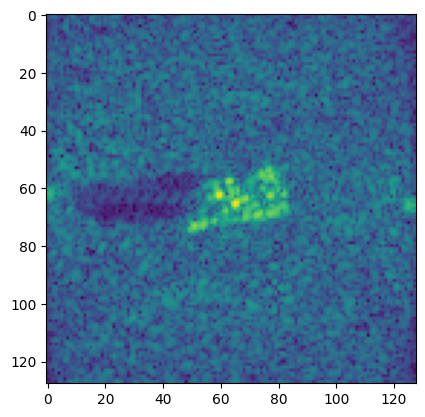

In [9]:
plt.imshow(image)
plt.show()

In [4]:
def readjust_intensity(image):
    return image / image.sum()

In [5]:
image_step0 = readjust_intensity(image)

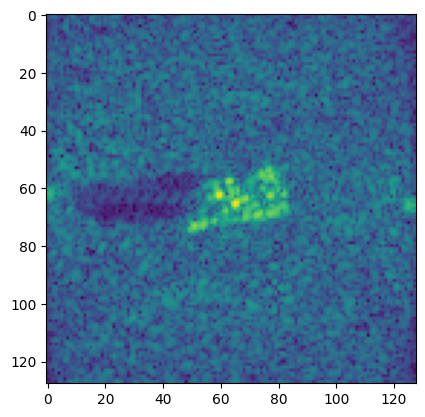

In [7]:
plt.imshow(image_step0)
plt.show()

In [6]:
def find_target_and_shadow_mask(image_step0):
    target_step1 = np.where(image_step0 >= np.percentile(image_step0, 97), 1, 0)
    shadow_step1 = np.where(image_step0 <= np.percentile(image_step0, 25), 1, 0)
    return target_step1, shadow_step1

In [20]:
target_step1, shadow_step1 = find_target_and_shadow_mask(image_step0)

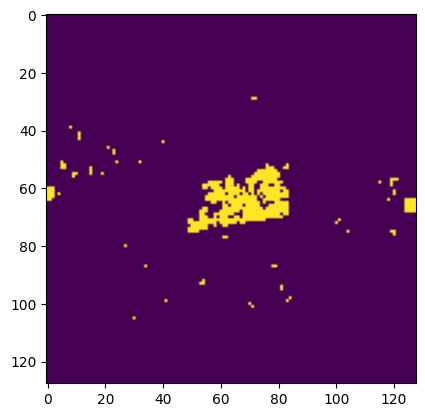

In [33]:
plt.imshow(target_step1)
plt.show()

In [37]:

def counting_filter(mask, window_size = 5, threshold = 15):
    neighbor_count = uniform_filter(mask.astype(float), size = window_size) * (window_size ** 2)
    return np.where(neighbor_count >= threshold, 1, 0)

In [38]:
target_step2, shadow_step2 = counting_filter(target_step1), counting_filter(shadow_step1)

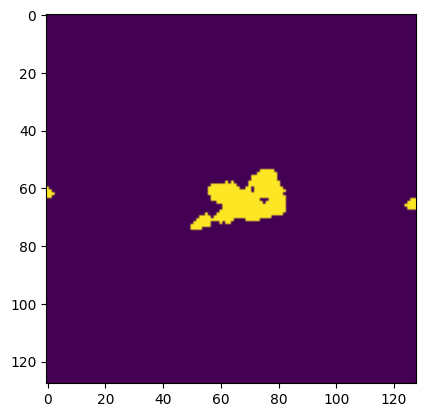

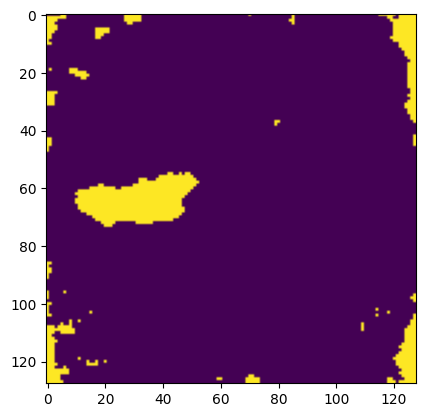

In [39]:
plt.imshow(target_step2)
plt.show()
plt.imshow(shadow_step2)
plt.show()

In [78]:
def structing_ele(shape = 5):
    ele = np.ones((shape, shape))
    ele[0, 0] = 0
    ele[0, -1] = 0
    ele[-1, 0] = 0
    ele[-1, -1] = 0
    return ele
def morphological_closing(mask, structuring_element = None):
    if structuring_element is None:
        structuring_element = structing_ele(shape = 5)
    return binary_closing(mask, structure = structuring_element).astype(bool)
    


In [41]:
target_step3, shadow_step3 = morphological_closing(target_step2), morphological_closing(shadow_step2)

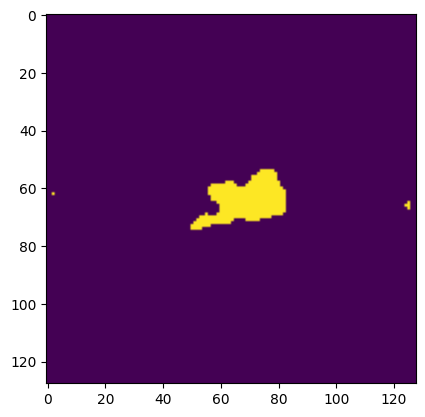

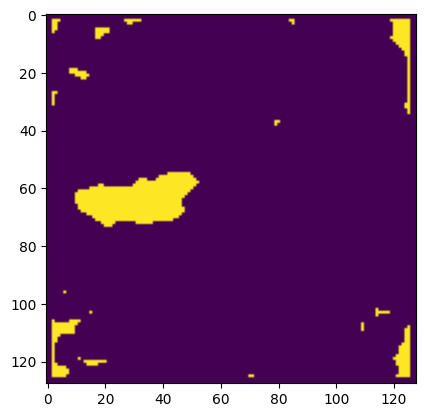

In [42]:
plt.imshow(target_step3)
plt.show()
plt.imshow(shadow_step3)
plt.show()

In [67]:
def find_largest_connected_component(mask):
    labeled_array, num_features = label(mask)
    if num_features == 0:
        return np.zeros_like(mask)
    largest_component = np.argmax(np.bincount(labeled_array.flat)[1:]) + 1
    return (labeled_array == largest_component).astype(int)

In [71]:
target_step4, shadow_step4 = find_largest_connected_component(target_step3), find_largest_connected_component(shadow_step3)

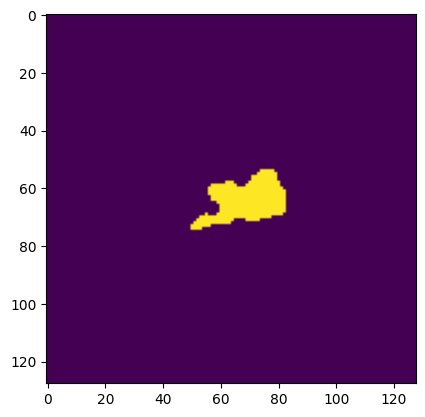

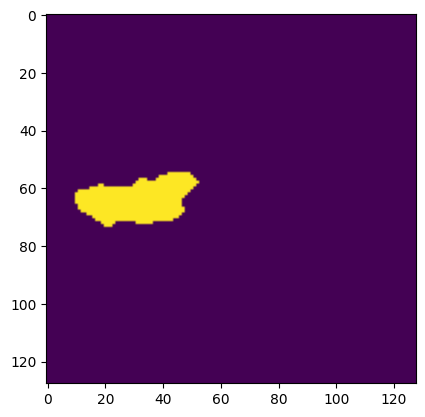

In [72]:
plt.imshow(target_step4)
plt.show()
plt.imshow(shadow_step4)
plt.show()

In [ ]:
def mask_to_intensity(mask, image_step0):
    return mask * image_step0

In [74]:
target_step5, shadow_step5 = mask_to_intensity(target_step4, image_step0), mask_to_intensity(shadow_step4, image_step0)

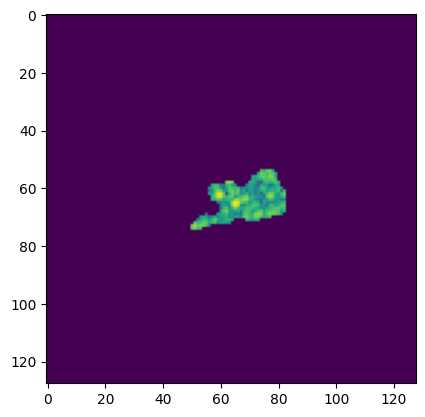

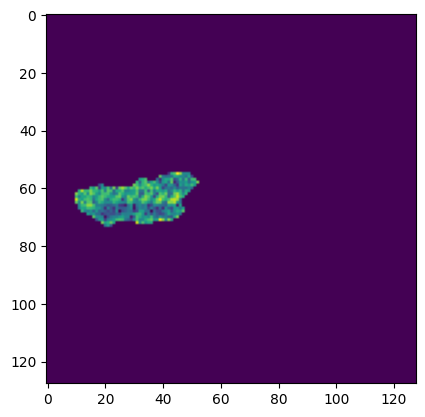

In [76]:
plt.imshow(target_step5)
plt.show()
plt.imshow(shadow_step5)
plt.show()

In [82]:
def choi_segmentation(image):
    image_step0 = readjust_intensity(image)
    target_step1, shadow_step1 = find_target_and_shadow_mask(image_step0)
    target_step2, shadow_step2 = counting_filter(target_step1), counting_filter(shadow_step1)
    target_step3, shadow_step3 = morphological_closing(target_step2), morphological_closing(shadow_step2)
    target_step4, shadow_step4 = find_largest_connected_component(target_step3), find_largest_connected_component(shadow_step3)
    clutter = 1 - (target_step4 + shadow_step4)
    # target_step5, shadow_step5 = mask_to_intensity(target_step4, image_step0), mask_to_intensity(shadow_step4, image_step0)
    return target_step4, shadow_step4, clutter